In [1]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Imports
from src.integrator.integrate import phi, phi_inv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e0 = 0.5

In [3]:
# LOAD INTERPOLATED D0 BOUNDARY
bound_tv = np.load("../boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy")

v_data = bound_tv[1,:-1]
t_data = bound_tv[0,:-1]

N = len(v_data)

# Fourier coefficients
c_four = np.fft.fft(v_data) / N

# integer wave numbers: 0,1,...,N/2-1,-N/2,...,-1
k_four = np.fft.fftfreq(N) * N

# We remove higher order modes (np.abs(c_four) <= 1e-5)
# They just represent noise
k_cut = 20
c_four[np.abs(k_four) > k_cut] = 0

def interpol_D0_v(t, noise_level = 8e-5):
    t = np.asarray(t) % (2*np.pi)   # enforce periodicity
    i_central = np.abs(c_four) >= noise_level
    phases = np.exp(1j * np.outer(k_four[i_central], t))
    vals = (c_four[i_central, None] * phases).sum(axis=0)
    return vals.real

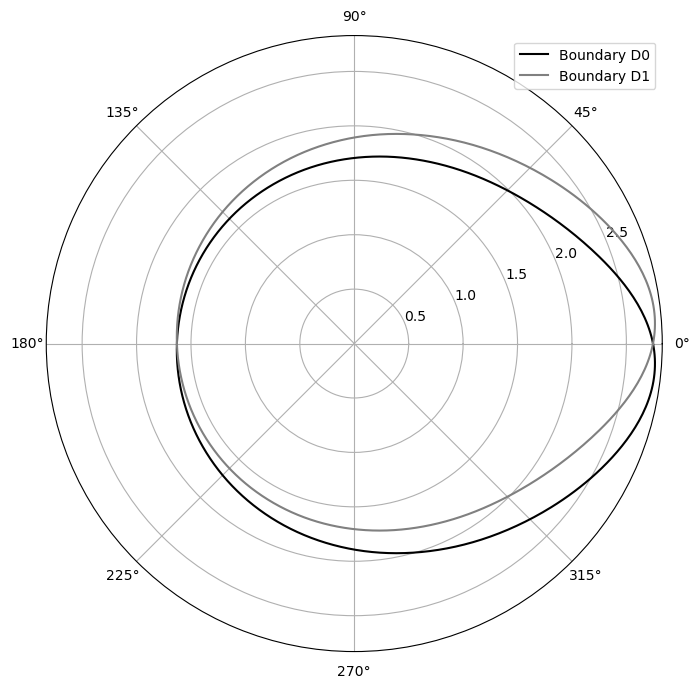

In [7]:
t_val = np.linspace(0, 2*np.pi, 500)
v_val = interpol_D0_v(t_val) # Assuming you want the boundary line too

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Plot the boundary line
ax.plot(t_val, v_val, color='black', label='Boundary D0')
ax.plot(-t_val, v_val, color='grey', label='Boundary D1')

plt.legend()
plt.show()

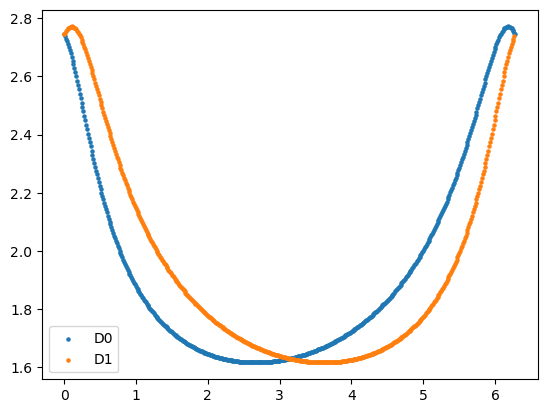

In [11]:
plt.scatter(t_val, v_val, s = 5, label = "D0")
plt.scatter( - t_val % (2*np.pi), v_val, s= 5, label = "D1")
plt.legend()
plt.show()